In [1]:
import glob
import os
from datasets import ClassLabel, Features, Value
from datasets import Dataset

def create_dataset_from_folder(root_path):
    classes = sorted([d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))])

    class_label_feature = ClassLabel(names=classes)

    image_paths = []
    labels = []

    for label_idx, class_name in enumerate(classes):
        class_dir = os.path.join(root_path, class_name)
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
            files = glob.glob(os.path.join(class_dir, ext))
            for file_path in files:
                image_paths.append(os.path.abspath(file_path))
                labels.append(label_idx)

    dataset = Dataset.from_dict({
        "image": image_paths,
        "label": labels
    })

    features = Features({
        "image": Value("string"),
        "label": class_label_feature
    })

    dataset = dataset.cast(features)

    return dataset


basepath = "data/Used_Cars_base_HPF_stack"
train_ds = create_dataset_from_folder(basepath + '/train')
test_ds = create_dataset_from_folder(basepath + '/test')

train_ds.save_to_disk('./hf_train_dataset')
test_ds.save_to_disk('./hf_test_dataset')
print("Datasets created successfully.")
print(f"Train size: {len(train_ds)}")
print(f"Test size: {len(test_ds)}")

Casting the dataset:   0%|          | 0/53226 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/12892 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/53226 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/12892 [00:00<?, ? examples/s]

Datasets created successfully.
Train size: 53226
Test size: 12892


In [2]:
from datasets import Dataset

train_dataset = Dataset.load_from_disk('./hf_train_dataset')
test_dataset = Dataset.load_from_disk('./hf_test_dataset')

{'image': Value(dtype='string', id=None), 'label': ClassLabel(names=['1시리즈_F20_2013_2015', '1시리즈_F20_2016_2019', '1시리즈_F40_2020_2024', '2008_2015_2017', '2시리즈_그란쿠페_F44_2020_2024', '2시리즈_액티브_투어러_F45_2019_2021', '2시리즈_액티브_투어러_U06_2022_2024', '3008_2세대_2018_2023', '3시리즈_E90_2005_2012', '3시리즈_F30_2013_2018', '3시리즈_G20_2019_2022', '3시리즈_G20_2023_2025', '3시리즈_GT_F34_2014_2021', '4시리즈_F32_2014_2020', '4시리즈_G22_2021_2023', '4시리즈_G22_2024_2025', '5008_2세대_2018_2019', '5008_2세대_2021_2024', '5시리즈_F10_2010_2016', '5시리즈_G30_2017_2023', '5시리즈_G60_2024_2025', '5시리즈_GT_F07_2010_2017', '6시리즈_F12_2011_2018', '6시리즈_GT_G32_2018_2020', '6시리즈_GT_G32_2021_2024', '718_박스터_2017_2024', '718_카이맨_2017_2024', '7시리즈_F01_2009_2015', '7시리즈_G11_2016_2018', '7시리즈_G11_2019_2022', '7시리즈_G70_2023_2025', '8시리즈_G15_2020_2024', '911_2003_2019', '911_992_2020_2024', 'A4_B9_2016_2019', 'A4_B9_2020_2024', 'A5_F5_2019_2024', 'A6_C8_2019_2025', 'A7_2012_2016', 'A7_4K_2020_2024', 'A8_D5_2018_2023', 'AMG_GT_2016_2024', 'A_클래스_W176_

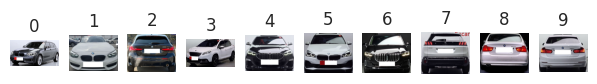

In [3]:
import PIL.Image as Image

labels = train_dataset.features['label'].names
print(train_dataset.features)
print("%d labels" % len(labels))
print(labels)

import matplotlib.pyplot as plt

shown_labels = set()
plt.figure(figsize=(300, 400))

for i, sample in enumerate(train_dataset):
    label = sample['label']
    if label not in shown_labels:
        shown_labels.add(label)
        plt.subplot(1, len(labels), len(shown_labels))
        print(sample['image'])
        plt.imshow(Image.open(sample['image']))
        plt.title(label)
        plt.axis('off')
        if len(shown_labels) == 10:
            break
plt.show()

In [4]:
import os
from sklearn.model_selection import train_test_split


id_to_label = {}
for sample in train_dataset:
    path = sample['image']
    file_id = os.path.splitext(os.path.basename(path))[0]
    if file_id not in id_to_label:
        id_to_label[file_id] = sample['label']

unique_ids = list(id_to_label.keys())
unique_labels = [id_to_label[uid] for uid in unique_ids]


id_train, id_val = train_test_split(
    unique_ids, 
    test_size=0.1, 
    stratify=unique_labels, 
    random_state=42 # Ensures reproducibility
)

id_train_set = set(id_train)
id_val_set = set(id_val)


def is_in_new_train(sample):
    fid = os.path.splitext(os.path.basename(sample['image']))[0]
    return fid in id_train_set

def is_in_new_val(sample):
    fid = os.path.splitext(os.path.basename(sample['image']))[0]
    return fid in id_val_set


new_train_dataset = train_dataset.filter(is_in_new_train)
new_val_dataset = train_dataset.filter(is_in_new_val)

dataset = {
    'train': new_train_dataset, 
    'val': new_val_dataset,
    'test': test_dataset
}

train_dataset = dataset['train']
val_dataset = dataset['val']
test_dataset = dataset['test']
print(dataset)

{'train': Dataset({
    features: ['image', 'label'],
    num_rows: 47902
}), 'val': Dataset({
    features: ['image', 'label'],
    num_rows: 5324
}), 'test': Dataset({
    features: ['image', 'label'],
    num_rows: 12892
})}


In [5]:
id2label = {id: label for id, label in enumerate(train_dataset.features['label'].names)}
label2id = {label: id for id, label in id2label.items()}
id2label, test_dataset[-1]['label'], id2label[test_dataset[-1]['label']]

({0: '1시리즈_F20_2013_2015',
  1: '1시리즈_F20_2016_2019',
  2: '1시리즈_F40_2020_2024',
  3: '2008_2015_2017',
  4: '2시리즈_그란쿠페_F44_2020_2024',
  5: '2시리즈_액티브_투어러_F45_2019_2021',
  6: '2시리즈_액티브_투어러_U06_2022_2024',
  7: '3008_2세대_2018_2023',
  8: '3시리즈_E90_2005_2012',
  9: '3시리즈_F30_2013_2018',
  10: '3시리즈_G20_2019_2022',
  11: '3시리즈_G20_2023_2025',
  12: '3시리즈_GT_F34_2014_2021',
  13: '4시리즈_F32_2014_2020',
  14: '4시리즈_G22_2021_2023',
  15: '4시리즈_G22_2024_2025',
  16: '5008_2세대_2018_2019',
  17: '5008_2세대_2021_2024',
  18: '5시리즈_F10_2010_2016',
  19: '5시리즈_G30_2017_2023',
  20: '5시리즈_G60_2024_2025',
  21: '5시리즈_GT_F07_2010_2017',
  22: '6시리즈_F12_2011_2018',
  23: '6시리즈_GT_G32_2018_2020',
  24: '6시리즈_GT_G32_2021_2024',
  25: '718_박스터_2017_2024',
  26: '718_카이맨_2017_2024',
  27: '7시리즈_F01_2009_2015',
  28: '7시리즈_G11_2016_2018',
  29: '7시리즈_G11_2019_2022',
  30: '7시리즈_G70_2023_2025',
  31: '8시리즈_G15_2020_2024',
  32: '911_2003_2019',
  33: '911_992_2020_2024',
  34: 'A4_B9_2016_2019',
  35: 'A4_B9

In [6]:
from transformers import ViTImageProcessor

model_name = 'google/vit-base-patch16-224'
processor = ViTImageProcessor.from_pretrained(model_name)
processor

2025-12-08 23:24:57.154582: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-08 23:24:57.154636: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-08 23:24:57.156011: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 23:24:57.161854: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-12-08 23:24:57.829468: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/home/ivory0321/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [7]:
from torchvision.transforms import (
    Compose,
    Normalize,
    ToTensor,
    CenterCrop,
    Resize,

)

In [8]:
import torch
from torchvision import transforms
size = processor.size['height']
image_mean, image_std = processor.image_mean, processor.image_std
normalize = Normalize(mean=image_mean, std=image_std)

def random_channel_shuffle(img):
    permutation = torch.randperm(3)
    return img[permutation, :, :]

train_transforms = Compose(
    [
        Resize(size=(size, size)),
        ToTensor(),
        transforms.Lambda(random_channel_shuffle),
        normalize,
    ]

)
val_transforms = Compose(
    [
        Resize(size=(size, size)),
        ToTensor(),
        normalize,
    ]
)
test_transforms = Compose(
    [
        Resize(size=(size, size)),
        ToTensor(),
        normalize,
    ]
)


def apply_train_transforms(samples):
    samples['pixel_values'] = [train_transforms(Image.open(image).convert('RGB')) for image in samples['image']]
    return samples


def apply_val_transforms(samples):
    samples['pixel_values'] = [val_transforms(Image.open(image).convert('RGB')) for image in samples['image']]
    return samples


def apply_test_transforms(samples):
    samples['pixel_values'] = [test_transforms(Image.open(image).convert('RGB')) for image in samples['image']]
    return samples


train_dataset.set_transform(apply_train_transforms)
val_dataset.set_transform(apply_val_transforms)
test_dataset.set_transform(apply_test_transforms)

In [9]:
from torch.utils.data import DataLoader


def collate_fn(examples):
    dict = {}
    pixel_values = torch.stack([example['pixel_values'] for example in examples])
    labels = torch.tensor([example['label'] for example in examples])

    dict['pixel_values'] = pixel_values
    dict['labels'] = labels
    return dict


sample_dataloader = DataLoader(train_dataset, collate_fn=collate_fn, batch_size=8)
batch = next(iter(sample_dataloader))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)

pixel_values torch.Size([8, 3, 224, 224])
labels torch.Size([8])


In [10]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
    attention_probs_dropout_prob=0.1,
    hidden_dropout_prob=0.1,
    # encoder_stride=16
)

# Unfreeze layers


for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

for layer in model.vit.encoder.layer:
    for param in layer.parameters():
        param.requires_grad = True
        
for param in model.vit.embeddings.parameters():
    param.requires_grad = True

print(model)
print('\nfine-tuning layers:')
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)





/home/ivory0321/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([396]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([396, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=7

In [16]:
from torch.optim import AdamW
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import log_loss
base_lr = 1.5e-4
weight_decay = 0.1

train_args = TrainingArguments(
    output_dir='output-models',
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    num_train_epochs=20,
    fp16=True,
    remove_unused_columns=False,
    learning_rate=base_lr,
    weight_decay=weight_decay,
    save_total_limit=2,
    push_to_hub=False,
    load_best_model_at_end=True,
    report_to=['tensorboard'],
    dataloader_pin_memory=True,
    dataloader_num_workers=12,
    metric_for_best_model="accuracy",
)
from evaluate import load
import scipy

metric = load("accuracy")


def compute_metrics(p):
    predictions, labels = p.predictions, p.label_ids
    probs = scipy.special.softmax(predictions, axis=-1)

    preds = np.argmax(predictions, axis=1)

    acc = metric.compute(predictions=preds, references=labels)['accuracy']

    class_labels = list(range(probs.shape[1]))
    try:
        ll = log_loss(labels, probs, labels=class_labels)
    except ValueError:
        ll = float('nan') 

    return {
        'accuracy': acc,
        'log_loss': ll
    }


def get_layer_wise_optimizer_params(model, base_lr, weight_decay, decay_factor=0.9):

    num_layers = 12
    optimizer_grouped_parameters = []

    no_decay = ["bias", "LayerNorm.weight", "norm.weight"]

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        scale = 1.0

        if "classifier" in name or "head" in name:
            scale = 1.0  
            

        elif "encoder.layer." in name:
            layer_idx = int(name.split("encoder.layer.")[1].split(".")[0])

            # Calculate decay: top and bottom layers (near 11 and 0) get higher LR
            # Layer 11,0 -> scale = 1.0
            # Layer 5,6  -> scale = 0.32
            dist_to_edge = min(layer_idx, num_layers - 1 - layer_idx)
            scale = decay_factor ** (dist_to_edge)
        else:
            scale = 1.0

        wd = 0.0 if any(nd in name for nd in no_decay) else weight_decay

        # 3. Add to group
        optimizer_grouped_parameters.append({
            "params": [param],
            "lr": base_lr * scale,
            "weight_decay": wd
        })

    return optimizer_grouped_parameters

opt_params = get_layer_wise_optimizer_params(
    model, 
    base_lr=base_lr, 
    weight_decay=weight_decay,
    decay_factor=0.9  # Try 0.8 (smaller dataset) to 0.95
)

optimizer = AdamW(opt_params, lr=base_lr)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    tokenizer=processor,
    compute_metrics=compute_metrics,
    # optimizers=(optimizer, None),
)

In [17]:

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Log Loss,Runtime,Samples Per Second,Steps Per Second
1,0.559700,0.519084,0.840533,0.519083,17.578000,302.879000,9.501000
2,0.201300,0.300779,0.899136,0.300779,15.784700,337.289000,10.580000
3,0.120100,0.272148,0.919421,0.272150,15.942400,333.952000,10.475000
4,0.074700,0.278767,0.924305,0.278772,15.969400,333.388000,10.458000
5,0.066200,0.287143,0.925620,0.287146,15.999400,332.762000,10.438000
6,0.034500,0.313861,0.924117,0.313872,15.851000,335.878000,10.536000
7,0.034700,0.273727,0.931630,0.273738,15.690100,339.321000,10.644000
8,0.028700,0.304858,0.926747,0.304875,16.012500,332.491000,10.429000
9,0.008600,0.311050,0.932006,0.311061,16.178500,329.079000,10.322000
10,0.030500,0.323719,0.927498,0.323675,16.066700,331.368000,10.394000


/home/ivory0321/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/ivory0321/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/ivory0321/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/ivory0321/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill result in an error.
  warnings.warn(
/home/ivory0321/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2916: UserWarning: The y_pred values do not sum to one. Starting from 1.5 thiswill re

TrainOutput(global_step=29940, training_loss=0.16292808273331708, metrics={'train_runtime': 4687.2441, 'train_samples_per_second': 204.393, 'train_steps_per_second': 6.388, 'total_flos': 7.450259075099689e+19, 'train_loss': 0.16292808273331708, 'epoch': 20.0})

# Visualization

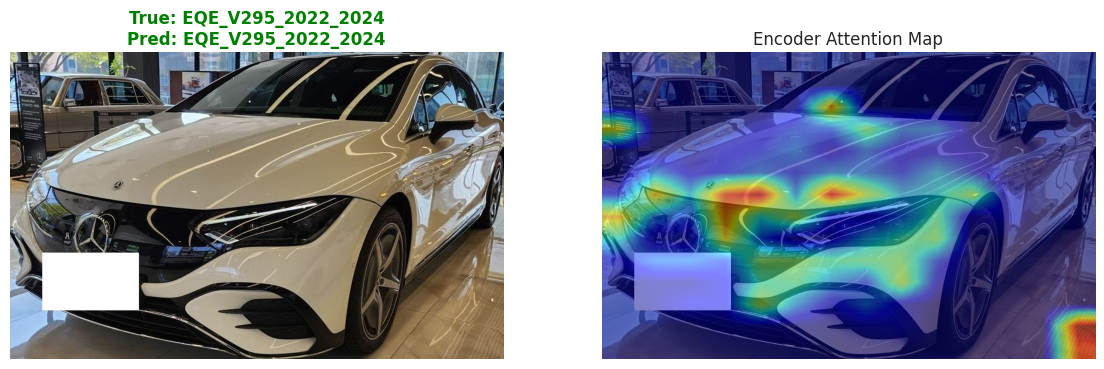

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

model = ViTForImageClassification.from_pretrained('models/Used_Cars_base_HPF_stack_2', output_attentions=True)
model.eval()

image_index = -7000


image_path = test_dataset[image_index]['image']
# image_path = "data/Used_Cars_base_HPF_stack/test/EQE_V295_2022_2024/EQE_V295_2022_2024_0057.jpg"
image = Image.open(image_path).convert("RGB")
true_label = id2label[test_dataset[image_index]['label']]
# true_label="EQE_V295_2022_2024"

def visualize(image, true_label):
    
    inputs = processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()
    predicted_label = id2label[predicted_class_idx]
    
    attentions = outputs.attentions[-1]
    att_mat = torch.mean(attentions, dim=1).squeeze(0)
    att_mat = att_mat[0, 1:]
    
    grid_size = int(np.sqrt(att_mat.shape[0]))
    att_grid = att_mat.reshape(grid_size, grid_size).numpy()
    
    att_map = cv2.resize(att_grid, (image.size[0], image.size[1]))
    att_map = (att_map - att_map.min()) / (att_map.max() - att_map.min())
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.imshow(image)
    title_color = 'green' if true_label == predicted_label else 'red'
    ax1.set_title(f"True: {true_label}\nPred: {predicted_label}", color=title_color, fontweight='bold')
    ax1.axis('off')
    
    ax2.imshow(image)
    ax2.imshow(att_map, cmap='jet', alpha=0.5)
    ax2.set_title("Encoder Attention Map")
    ax2.axis('off')
    
    plt.show()
visualize(image, true_label)

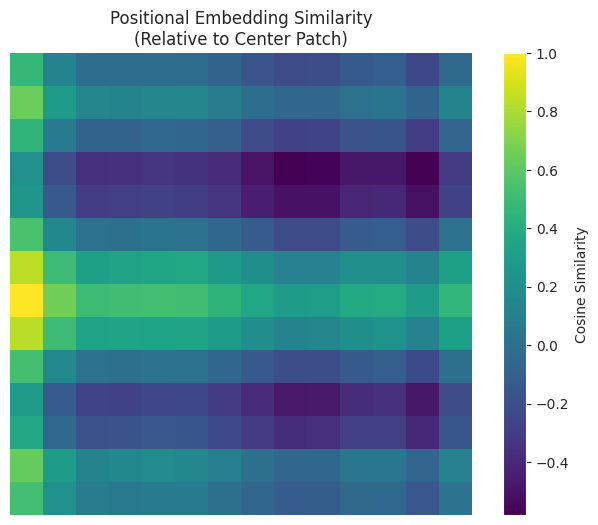

In [32]:
import math
from torch.nn.functional import cosine_similarity

pos_embed = model.vit.embeddings.position_embeddings
pos_embed = pos_embed[:, 1:, :]

num_patches = pos_embed.shape[1]
grid_size = int(math.sqrt(num_patches))

center_idx = num_patches // 2
center_embed = pos_embed[:, center_idx, :]

sim = cosine_similarity(center_embed, pos_embed[0], dim=1)
sim_grid = sim.reshape(grid_size, grid_size).detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(sim_grid, cmap='viridis')
plt.colorbar(label='Cosine Similarity')
plt.title(f'Positional Embedding Similarity\n(Relative to Center Patch)')
plt.axis('off')
plt.show()

# Evaluation

# Multi-voting 

In [25]:
from tqdm import tqdm
from collections import defaultdict
def get_paired_test_samples(dataset):

    grouped_data = defaultdict(dict)
    
    print("Grouping test samples...")
    for sample in tqdm(dataset):
        path = sample['image']
        label = sample['label']
        
        filename = os.path.basename(path)
        file_id, ext = os.path.splitext(filename)
        
        if ext.lower() in ['.jpg', '.jpeg']:
            grouped_data[file_id]['jpg'] = path
        elif ext.lower() == '.png':
            grouped_data[file_id]['png'] = path
        grouped_data[file_id]['label'] = label

    paired_samples = []
    for file_id, data in grouped_data.items():
        if 'jpg' in data and 'png' in data:
            paired_samples.append(data)
        else:
            pass
            
    print(f"Found {len(paired_samples)} paired samples.")
    return paired_samples

paired_test_samples = get_paired_test_samples(test_dataset)



Grouping test samples...


100%|██████████| 12892/12892 [05:01<00:00, 42.73it/s]

Found 6446 paired samples.


In [29]:
from sklearn.metrics import accuracy_score
def evaluate_multivoting(model, paired_samples, processor, device):
    model.eval()
    model.to(device)
    
    predictions = []
    true_labels = []
    
    print("Running Multi-view Inference...")
    
    with torch.no_grad():
        for sample in tqdm(paired_samples):
            image_rgb = Image.open(sample['jpg']).convert('RGB')
            image_hpf = Image.open(sample['png']).convert('RGB')
            label = sample['label']
            
            inputs_rgb = processor(images=image_rgb, return_tensors="pt").to(device)
            inputs_hpf = processor(images=image_hpf, return_tensors="pt").to(device)
            
            outputs_rgb = model(**inputs_rgb)
            outputs_hpf = model(**inputs_hpf)
            
            combined_logits = 1*outputs_rgb.logits + 1*outputs_hpf.logits
            
            pred_label = torch.argmax(combined_logits, dim=-1).item()
            
            predictions.append(pred_label)
            true_labels.append(label)

    acc = accuracy_score(true_labels, predictions)
    return acc, predictions, true_labels

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()

voting_accuracy, all_preds, all_labels = evaluate_multivoting(
    model, 
    paired_test_samples, 
    processor, 
    device
)

print(f"\nMulti-view (RGB + HPF) Voting Accuracy: {voting_accuracy:.4f}")

Running Multi-view Inference...


100%|██████████| 6446/6446 [08:48<00:00, 12.20it/s]


Multi-view (RGB + HPF) Voting Accuracy: 0.9474


In [30]:
import sklearn.metrics as metrics

print(metrics.classification_report(all_labels, all_preds))
print(metrics.recall_score(all_labels, all_preds, average='weighted'))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        17
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00        15
           3       1.00      1.00      1.00        17
           4       0.94      0.88      0.91        17
           5       1.00      1.00      1.00        12
           6       1.00      0.94      0.97        16
           7       1.00      0.53      0.69        17
           8       1.00      0.94      0.97        17
           9       0.77      1.00      0.87        17
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        17
          12       1.00      1.00      1.00        17
          13       1.00      0.88      0.94        17
          14       0.79      0.69      0.73        16
          15       0.57      0.53      0.55        15
          16       0.62      1.00      0.76        16
          17       0.85    

# Regular inference

In [ ]:
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

batch_size = 32
all_logits = []
true_labels = []

num_samples = len(test_dataset)

with torch.no_grad():
    for i in tqdm(range(0, num_samples, batch_size), desc="Processing Batches"):
        end_idx = min(i + batch_size, num_samples)
        batch_indices = range(i, end_idx)

        batch_items = [test_dataset[idx] for idx in batch_indices]

        batch_images = [Image.open(item['image']).convert("RGB") for item in batch_items]
        batch_labels = [item['label'] for item in batch_items]

        inputs = processor(images=batch_images, return_tensors="pt").to(device)

        outputs = model(**inputs)
        all_logits.append(outputs.logits.cpu())
        true_labels.extend(batch_labels)

logits = torch.cat(all_logits, dim=0).numpy()
true_labels = np.array(true_labels)

print(f"Inference complete. Logits shape: {logits.shape}")

probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
pred_labels = np.argmax(probs, axis=1)

print(f"Accuracy: {np.mean(pred_labels == true_labels):.4f}")

In [20]:
import sklearn.metrics as metrics

print(metrics.classification_report(true_labels, pred_labels))
print(metrics.recall_score(true_labels, pred_labels, average='weighted'))

NameError: name 'true_labels' is not defined

In [21]:
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, roc_curve, auc
import pandas as pd
from sklearn.preprocessing import label_binarize
import seaborn as sns

print("\n--- Metrics ---")
acc = accuracy_score(true_labels, pred_labels)
loss = log_loss(true_labels, probs)

results = {
    "Accuracy": acc,
    "Log Loss": loss,
}

results_df = pd.DataFrame([results])
print(results_df.T)

print("\n--- Confusion Matrix ---")

class_names = test_dataset.features['label'].names

cm = confusion_matrix(true_labels, pred_labels)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

cm_df.to_csv("confusion_matrix.csv")
print("Confusion matrix saved to 'confusion_matrix.csv'")

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- ROC Curves ---")

y_test_bin = label_binarize(true_labels, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(12, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1, alpha=0.5,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-average (AUC = {roc_auc["micro"]:.2f})',
         color='black', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.show()


--- Metrics ---


NameError: name 'true_labels' is not defined